**Q2. Unsupervised Learning**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


**1. Data Preparation**

In [32]:
# Read the CSV file into a DataFrame
df_customers = pd.read_csv('../data/q2_customers.csv')

# Scale all the features using StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_customers)

# Create a DataFrame for the scaled data
df_scaled = pd.DataFrame(scaled_features, columns=df_customers.columns)

print("Data loaded and scaled successfully.")
df_scaled.head()


Data loaded and scaled successfully.


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Essential Before Applying K-Means

K-Means clustering works by calculating the **Euclidean distance** between data points and cluster centroids. The problem is that our dataset features operate on very different numerical scales — `annual_spend` can be in the tens of thousands, while `visits_per_month` is typically a single-digit number.

Because of this imbalance, features with larger magnitudes end up dominating the distance calculation. A small difference in `annual_spend` would outweigh a large difference in `visits_per_month`, making the algorithm almost blind to the smaller-scale features.

To fix this, I applied `StandardScaler`, which transforms each feature to have a mean of 0 and a standard deviation of 1. This way, no single feature gets an unfair advantage just because of how it happens to be measured, and the clustering reflects genuine behavioral differences rather than unit differences.

**2. Choosing K-Elbow Method**

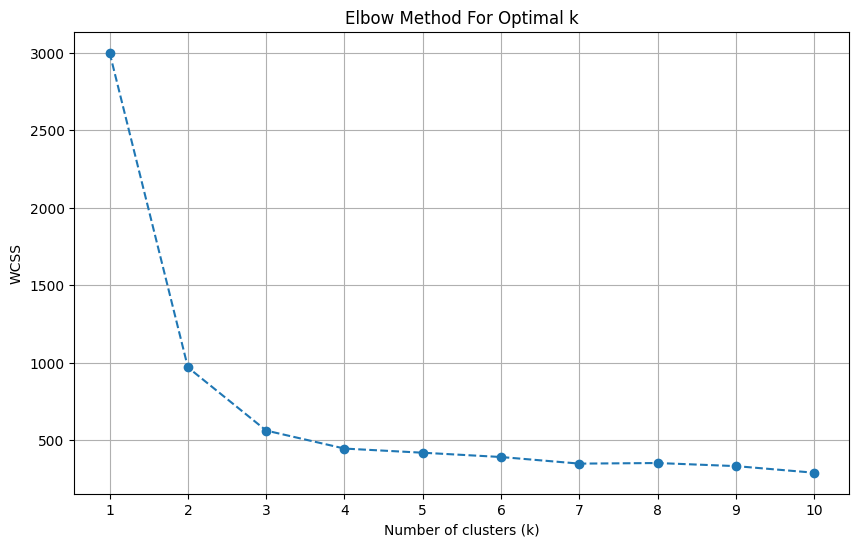

In [33]:
# WCSS list to store inertia values
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()


### Choosing Optimal K — Elbow Method

To find the right number of clusters, I calculated and plotted the **Within-Cluster Sum of Squares (WCSS)** for K values ranging from 1 to 10. 

**Observations from the Plot:**
* **Steep Drop (K=1 to K=3):** The WCSS falls sharply in this range, dropping from approximately **3000 down to 600**. This indicates that moving to 3 clusters significantly increases the compactness of the groups.
* **The "Elbow" Point:** A clear bend is visible at **K = 3**, where the WCSS stops dropping rapidly and begins to flatten out.
* **Flattening (Beyond K=3):** From K = 4 onwards, each additional cluster offers only a small reduction in WCSS. The improvement no longer justifies the added complexity.

**Selected K = 3**

K = 3 strikes the best balance between model simplicity and clustering quality. It captures the natural groupings in the data without overfitting to noise, and each cluster maps cleanly onto a distinct type of customer behaviour.

**3. K-Means Clustering**

In [34]:
# Fit K-Means with the optimal number of clusters (k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# Add a cluster column to the dataframe
df_customers['cluster'] = kmeans.fit_predict(df_scaled)

# Print the cluster centroids as a readable dataframe
# We use inverse_transform to turn those scaled decimals back into real-world numbers
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

df_centroids = pd.DataFrame(
    centroids,
    columns=df_customers.columns[:-1],   # Exclude the 'cluster' column name itself
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

print("--- Cluster Centroids (Business Values) ---")
df_centroids

--- Cluster Centroids (Business Values) ---


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
Cluster 1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
Cluster 2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Business Interpretation of Customer Clusters

After fitting K-Means with K=3, three distinct customer groups emerged from the centroid values:

* **Cluster 0 — Young Frequent Budget Shoppers:**
  These are the youngest customers (avg. age **~25**) who visit most often — around **14 times a month** — but spend the least annually (**~$14,847**), with a small basket size of around **559** and purchases spread across only **~2 categories**. They are highly active but low in value per visit, shopping in a very narrow range of product categories.

* **Cluster 1 — Older High-Value Dormant Shoppers:**
  The oldest segment (avg. age **~57**) that spends the most annually (**~$89,413**), has the largest basket size (**~5,531**), and shops across the widest range of categories (**~7.5 categories**). However, they visit only about **2–3 times a month** and haven't visited in over **105 days** on average. They are clearly high-value customers who are at risk of churning and would benefit most from targeted re-engagement or loyalty campaigns.

* **Cluster 2 — Middle-Aged Balanced Shoppers:**
  A balanced middle segment (average age **~40**) with moderate annual spend (**~$43,341**), moderate visit frequency (**8 visits/month**), and **~35 days** 
  since last visit. With a medium basket size (**~2,022**) and **4.4 categories**, these are steady, reliable customers who form the backbone of the customer base and are the most likely to respond positively to loyalty rewards or cross-sell campaigns.

**4. Dimensionality Reduction with PCA**

In [35]:
# Apply PCA to reduce the data to 2 principal components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# Create a DataFrame for the PCA results
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])

# Print the explained variance ratio for each component
print("Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")
    
# Print the feature loadings (components) as a readable dataframe
# The loadings show how much each original feature contributes to the principal components
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_customers.columns[:-1]  # Exclude the 'cluster' column
)
print("\nFeature Loadings for PC1 and PC2:")
loadings

Explained Variance Ratio:
PC1: 0.8356
PC2: 0.0557

Feature Loadings for PC1 and PC2:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### Interpretation of Principal Components (PC1 and PC2)

The first two principal components together explain approximately **89.13%** of the total variance in the customer dataset (PC1: **83.56%**, PC2: **5.57%**).
The fact that PC1 alone captures so much variance suggests there is one strong underlying pattern driving most of the differences between customers.

**PC1 — Overall Customer Value:**
PC1 has high positive loadings from **age** (0.41), **annual_spend** (0.42), **basket_size** (0.41), and **num_categories_purchased** (0.41), while **visits_per_month** has a strong negative loading (-0.41). This means PC1 captures the core trade-off between spending power and visit frequency. Customers with a high PC1 score tend to be older, spend more annually, and shop across a wider range of categories, but visit far less often. On the opposite end, a low PC1 score points to younger, frequent shoppers with smaller baskets and lower overall spend.

**PC2 — Recency:**
PC2 is almost entirely driven by **days_since_last_visit** (0.91), with all other features contributing minimally. This component purely captures how recently a customer has visited — a high PC2 score indicates a customer who has not visited in a long time (potential churn risk).

By reducing the data to these two components, we can visualize the clusters on a 2D plane while retaining **89.13%** of the original information.

**5. Cluster Visualisation**

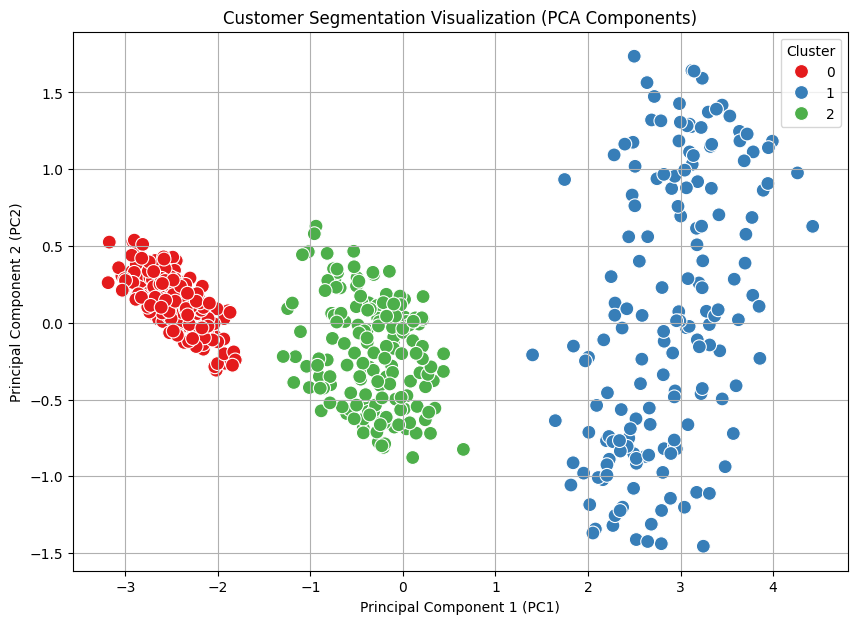

In [36]:
# Create a scatter plot of PC1 vs PC2 with points colored by cluster label
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_pca['PC1'],
    y=df_pca['PC2'],
    hue=df_customers['cluster'],
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation Visualization (PCA Components)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
